In [3]:
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("used_cars_1M_2025.csv")
df.head(10)

,id,country,city,brand,model,year,mileage_km,price_usd,fuel_type,transmission,horsepower,doors,color,condition_score,days_on_market,is_electric
0,134118,Germany,NaN,Hyundai,Elantra,2004.0,300092.0,3272.0,NaN,Automatic,643.0,4.0,Black,NaN,144.0,0
1,1421168,Germany,Brand,Toyota,Highlander,2024.0,51510.0,32817.0,Gasoline,Automatic,296.0,3.0,White,3.7,300.0,0
2,159489,NaN,Erding,Audi,A6,2004.0,261436.0,NaN,Gasoline,Automatic,499.0,4.0,Blue,5.2,311.0,0
3,2020959,France,Saint Suzanne-sur-Mer,Subaru,Impreza,2020.0,67330.0,21297.0,Gasoline,Automatic,317.0,4.0,Yellow,7.1,266.0,0
4,1410751,Germany,Reutlingen,Hyundai,Santa Fe,2011.0,231561.0,5525.0,Plug-in Hybrid,Automatic,575.0,4.0,Green,NaN,324.0,0
5,2220993,Germany,Erfurt,Toyota,NaN,2008.0,213042.0,3312.0,Electric,Manual,378.0,4.0,Silver,6.9,123.0,0
6,1264579,USA,Lake Diane,Mercedes-Benz,C-Class,2005.0,245308.0,NaN,Gasoline,Automatic,313.0,4.0,Blue,6.5,NaN,0
7,118199,NaN,Lake Robertport,Audi,A3,2019.0,75086.0,28988.0,Gasoline,Automatic,551.0,5.0,Green,7.8,NaN,0
8,1137565,Germany,NaN,Hyundai,Elantra,2025.0,11257.0,51662.0,Gasoline,Automatic,411.0,5.0,NaN,NaN,292.0,0
9,2098664,UK,Lake Nicolaborough,Kia,Sportage,2018.0,160115.0,17626.0,Gasoline,Automatic,196.0,4.0,Orange,6.2,169.0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 16 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   id               1000000 non-null  int64  
 1   country          881843 non-null   object 
 2   city             902721 non-null   object 
 3   brand            902415 non-null   object 
 4   model            902449 non-null   object 
 5   year             902612 non-null   float64
 6   mileage_km       902434 non-null   float64
 7   price_usd        902622 non-null   float64
 8   fuel_type        902056 non-null   object 
 9   transmission     902442 non-null   object 
 10  horsepower       902410 non-null   float64
 11  doors            902363 non-null   float64
 12  color            902326 non-null   object 
 13  condition_score  902988 non-null   float64
 14  days_on_market   902169 non-null   float64
 15  is_electric      1000000 non-null  int64  
dtypes: float64(7), int6

In [6]:
df.drop("id", axis=1, inplace=True)

In [7]:
df.describe()

,year,mileage_km,price_usd,horsepower,doors,condition_score,days_on_market,is_electric
count,902612.000000,9.024340e+05,9.026220e+05,902410.000000,902363.000000,902988.000000,902169.000000,1000000.000000
mean,2010.008005,2.149292e+05,1.181264e+04,369.703736,4.148898,6.669321,182.737671,0.110075
std,8.944948,1.150328e+05,1.675404e+04,161.524345,0.726185,2.009265,105.110314,0.312983
min,1995.000000,-4.922871e+04,-9.571406e+02,90.000000,2.000000,0.100000,1.000000,0.000000
25%,2002.000000,1.210180e+05,2.441000e+03,230.000000,4.000000,5.300000,92.000000,0.000000
50%,2010.000000,2.148695e+05,6.652000e+03,370.000000,4.000000,6.900000,183.000000,0.000000
75%,2018.000000,3.076640e+05,1.641300e+04,510.000000,5.000000,8.300000,274.000000,0.000000
max,2025.000000,4.962021e+06,1.900538e+06,649.000000,5.000000,10.000000,364.000000,1.000000


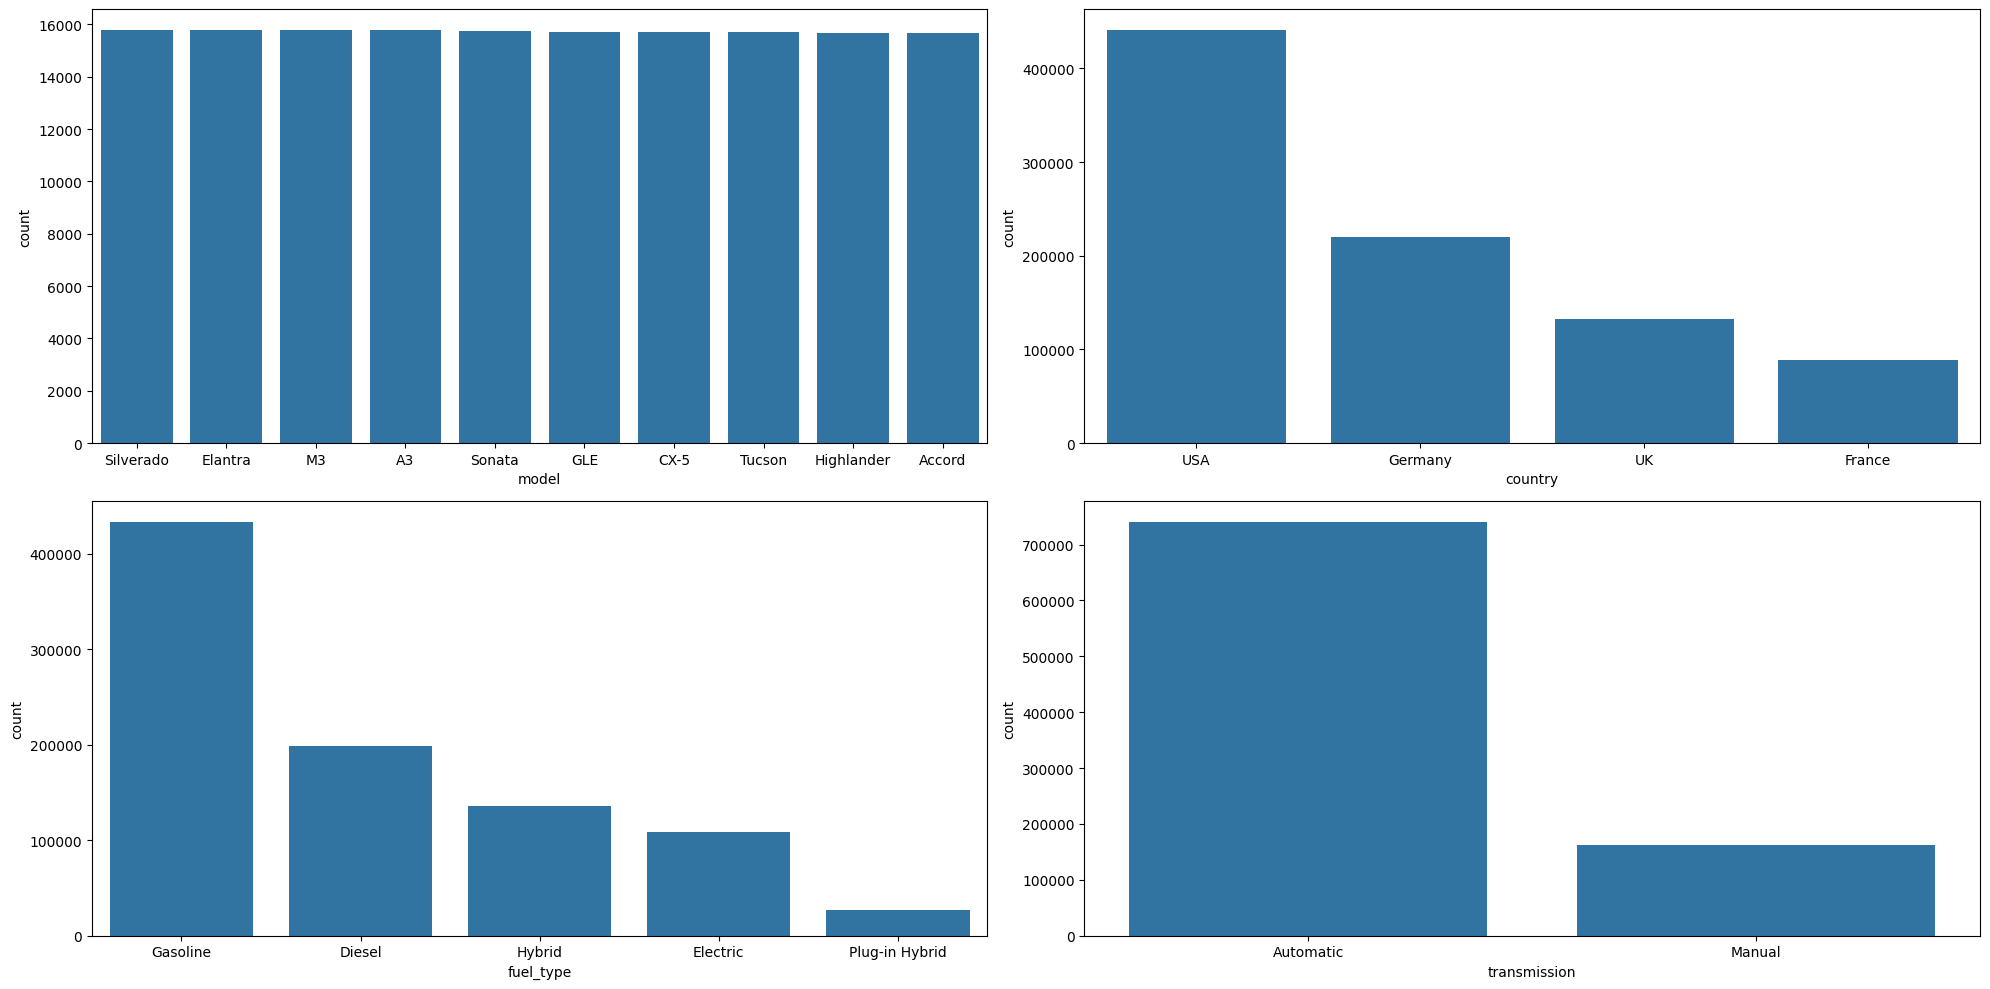

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))

sns.countplot(data=df, x="model", ax=axes[0, 0], order=df["model"].value_counts().nlargest(10).index)
sns.countplot(data=df, x="country", ax=axes[0, 1], order=df["country"].value_counts().nlargest(10).index)
sns.countplot(data=df, x="fuel_type", ax=axes[1, 0], order=df["fuel_type"].value_counts().nlargest(10).index)
sns.countplot(data=df, x="transmission", ax=axes[1, 1], order=df["transmission"].value_counts().nlargest(10).index)

plt.tight_layout()
plt.show()

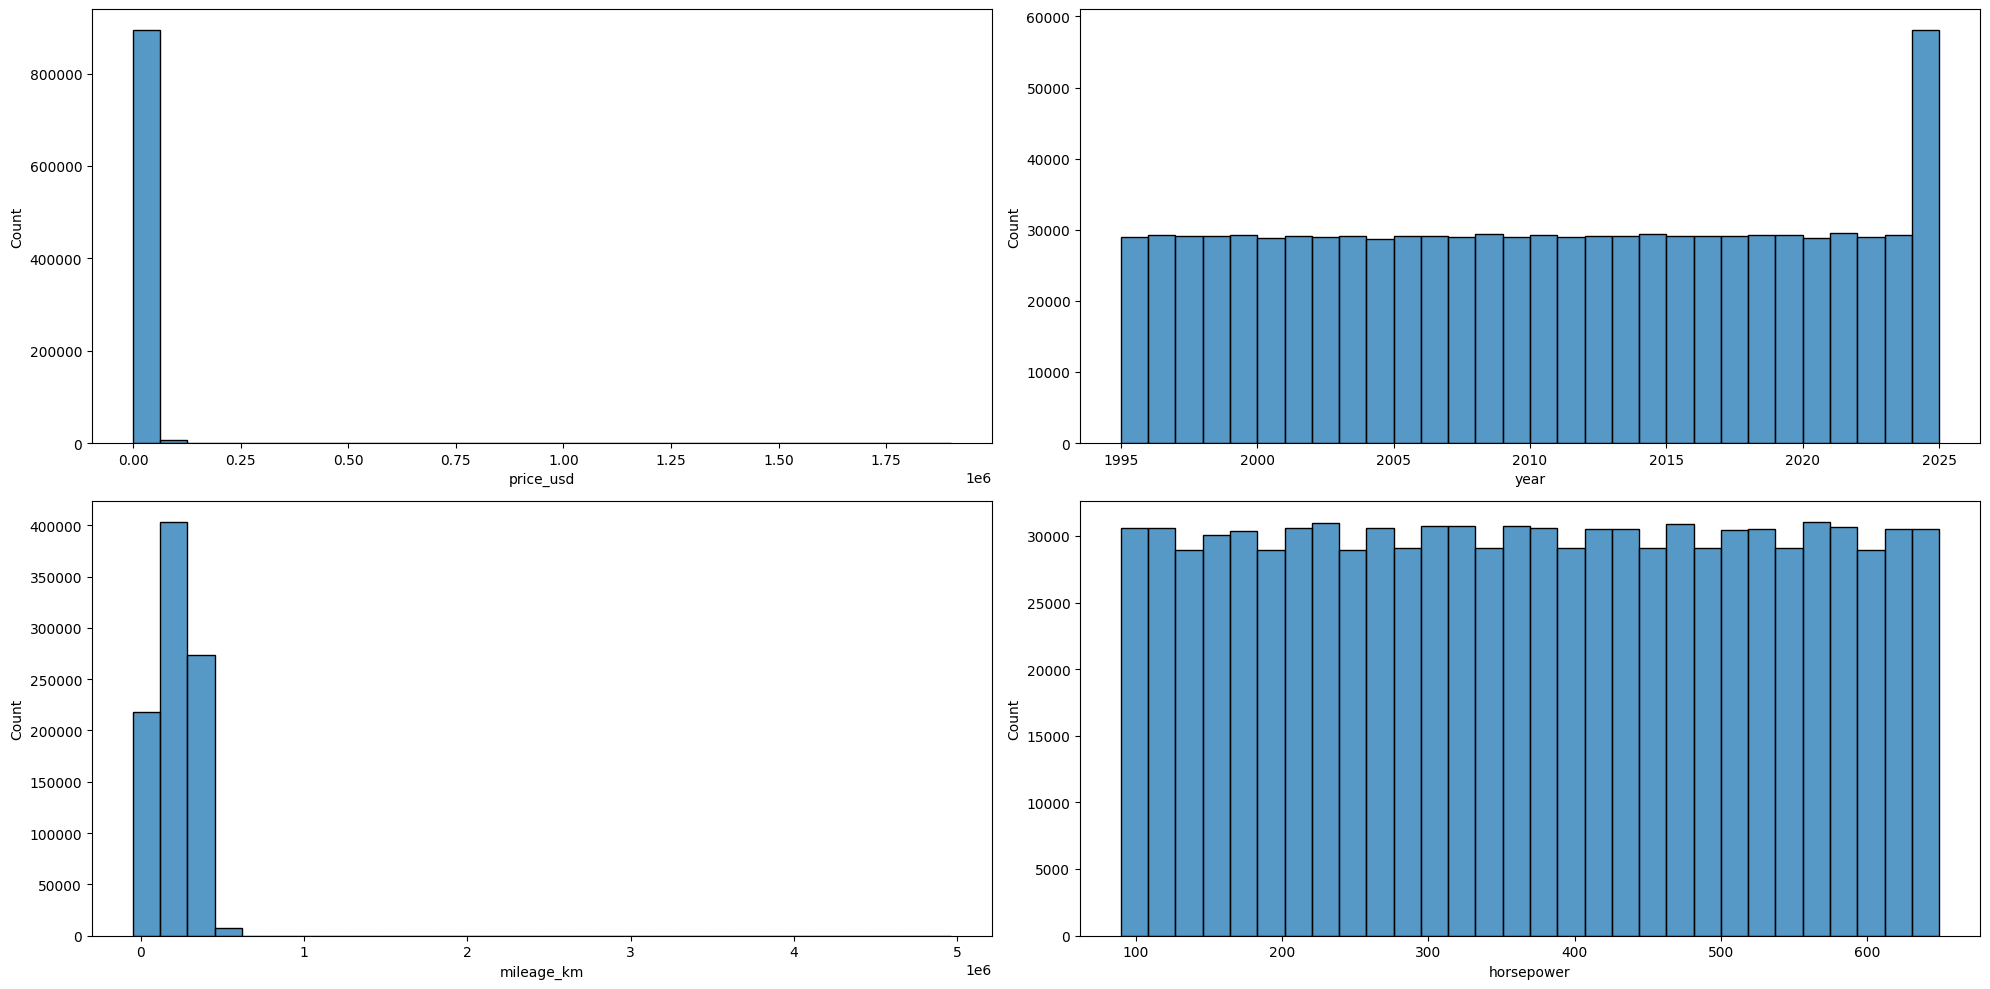

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))

sns.histplot(data=df, x="price_usd", ax=axes[0, 0], bins=30)
sns.histplot(data=df, x="year", ax=axes[0, 1], bins=30)
sns.histplot(data=df, x="mileage_km", ax=axes[1, 0], bins=30)
sns.histplot(data=df, x="horsepower", ax=axes[1, 1], bins=30)

plt.tight_layout()
plt.show()

In [10]:
df.isnull().sum()

country            118157
city                97279
brand               97585
model               97551
year                97388
mileage_km          97566
price_usd           97378
fuel_type           97944
transmission        97558
horsepower          97590
doors               97637
color               97674
condition_score     97012
days_on_market      97831
is_electric             0
dtype: int64

In [11]:
numeric_cols = ['price_usd', 'mileage_km', 'horsepower']
for col in numeric_cols:
    df[col].fillna(df[col].median())

df.dropna(inplace=True)

In [12]:
df.isnull().sum()

country            0
city               0
brand              0
model              0
year               0
mileage_km         0
price_usd          0
fuel_type          0
transmission       0
horsepower         0
doors              0
color              0
condition_score    0
days_on_market     0
is_electric        0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(4777)

In [14]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

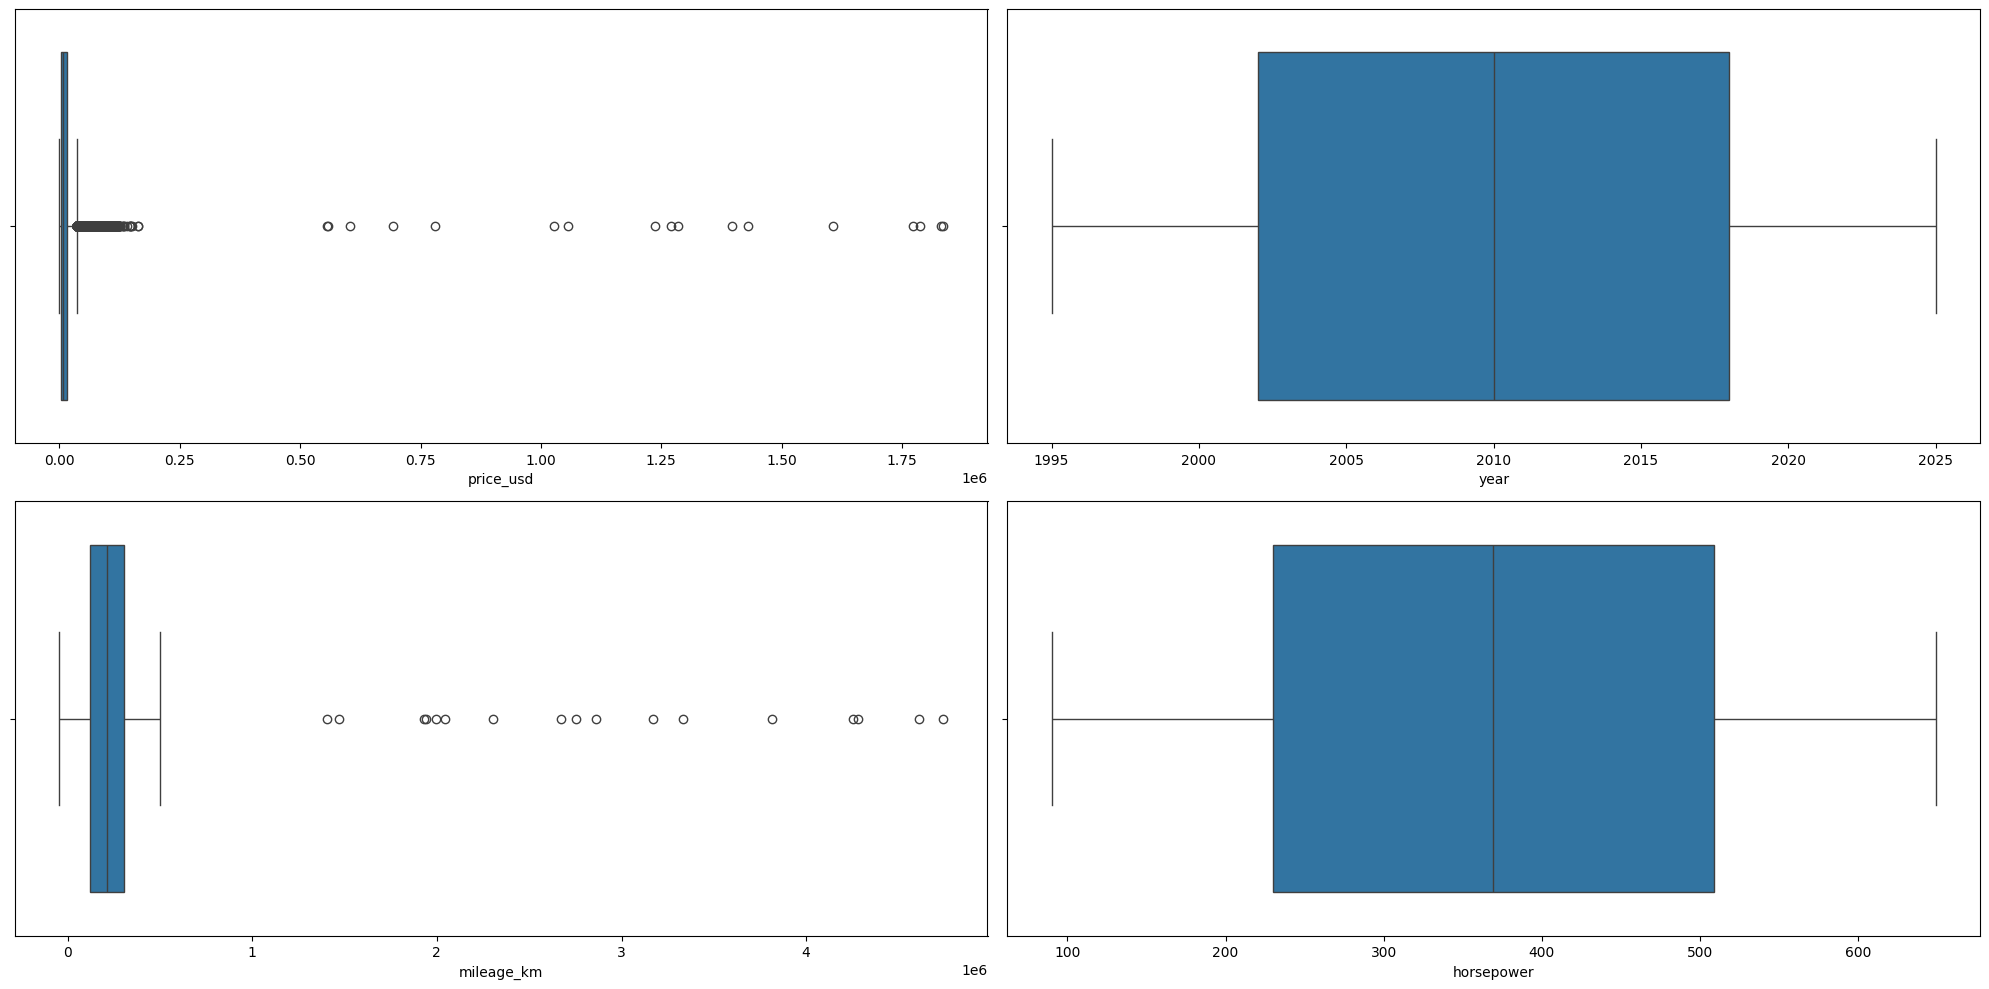

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))

sns.boxplot(data=df, x="price_usd", ax=axes[0, 0])
sns.boxplot(data=df, x="year", ax=axes[0, 1])
sns.boxplot(data=df, x="mileage_km", ax=axes[1, 0])
sns.boxplot(data=df, x="horsepower", ax=axes[1, 1])

plt.tight_layout()
plt.show()

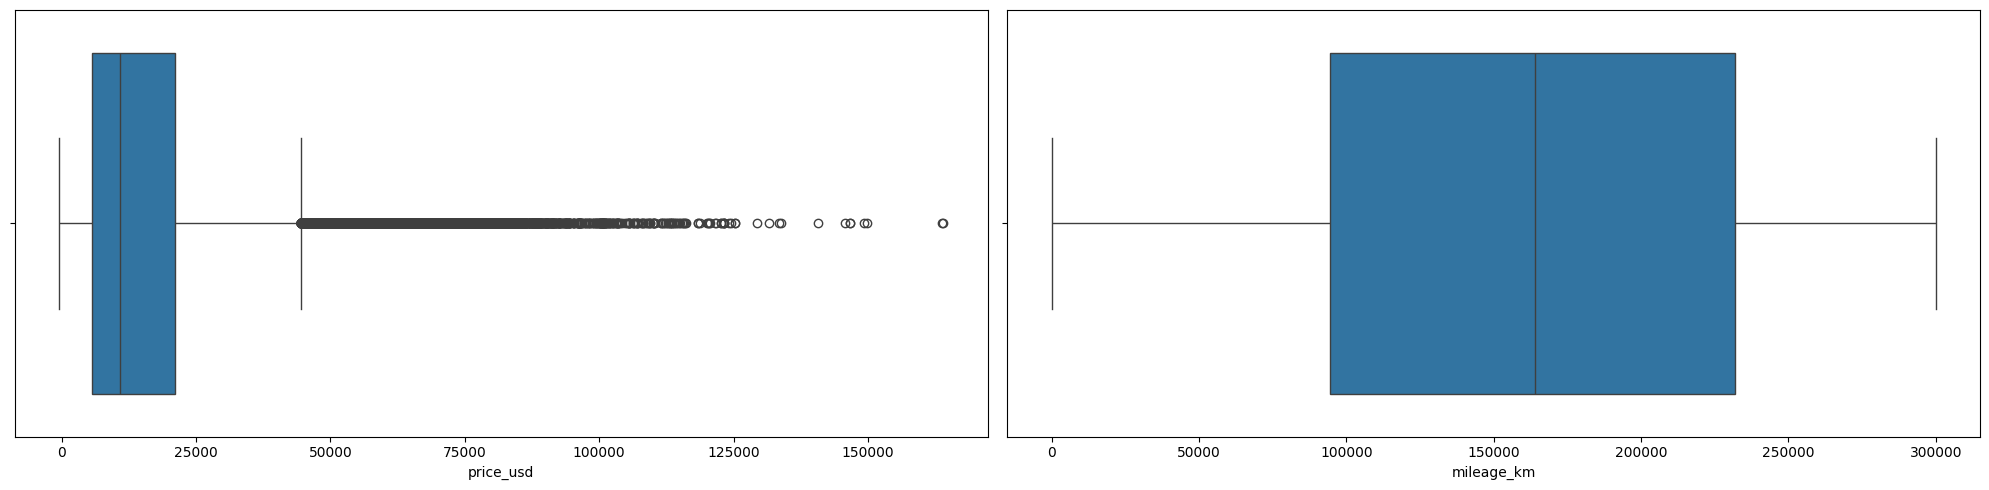

In [16]:
df = df.drop(df[df["price_usd"] > 250000].index)
df = df.drop(df[(df["mileage_km"] > 300000) | (df["mileage_km"] < 0)].index)

fig, axes = plt.subplots(1, 2, figsize=(20, 5))
sns.boxplot(data=df, x="price_usd", ax=axes[0])
sns.boxplot(data=df, x="mileage_km", ax=axes[1])

plt.tight_layout()
plt.show()